# MLflow: tune, register, serve, package — Maré Hotels' cancellation model

**A tuned model goes through the Model Registry to a live endpoint, and the next model takes its place without a code change; then the training job is packaged, so anyone can run it.**

- **The business:** Maré Hotels runs a city hotel in Lisbon and a resort in the Algarve. Every upcoming booking gets a P(cancel); the revenue team reconfirms the ones at 0.5 or above and overbooks against the rest.
- **Where it starts:** `train.py` trains the model, an XGBoost classifier, and tracks each run in MLflow. Today's model scores 0.9017 test ROC-AUC. It exists as a run and a logged model, but nothing records that it's the one in use, and replacing it means re-pointing everything that loads it.
- **Where it ends:** a tuned challenger, both models as versions of `booking-cancellation` in the Model Registry, two endpoints answering from `@champion`, and the challenger promoted by moving that one alias. Then `train.py` becomes an MLflow Project, two named commands and a declared environment, and one of them rebuilds the champion from its own run.

| Part | Step | MLflow (and friends) you use | You end up with |
|---|---|---|---|
| P1 | Today's model | `train.py` · runs · logged models | run `xgb-depth6`: test ROC-AUC 0.9017 |
| P2 | Tune | Optuna · nested runs · `search_runs` · a config handed over as an artifact | 20 trials under `tune-xgb`; the challenger run `xgb-tuned` |
| P3 | Register | Model Registry: versions · aliases · descriptions · tags | `booking-cancellation` version 1 `@champion`, version 2 `@challenger` |
| P4 | Serve | `mlflow models serve` · signatures · FastAPI + pydantic | `POST /invocations`; `app.py` with `POST /predict` and `GET /health` |
| P5 | Promote | a gate in code · `set_registered_model_alias` | `@champion` → version 2, and both endpoints answering with it |
| P6 | Package | MLflow Projects: `MLproject` · entry points · `mlflow run` | runs `project-train` and `project-retrain`; the champion rebuilt, test ROC-AUC 0.9169 again |
| P7 | Wrap-up | | the whole path on one page |

### What gets built

**Two HTTP endpoints serve the same registered model; only one of them checks values.**

| Route | Served by | Called by | Answers | Built in |
|---|---|---|---|---|
| `POST /invocations` | `mlflow models serve` | services and batch jobs that already hold the model's 20 columns | `{"predictions": [[P(kept), P(cancelled)]]}` | P4 |
| `GET /ping` | `mlflow models serve` | a load balancer | 200 once the model is loaded | P4 |
| `POST /predict` | `app.py` (FastAPI) | the booking engine | `p_cancel`, `reconfirm`, `threshold`, `model_version` | P4 |
| `GET /health` | `app.py` | monitoring | which model version is answering | P4 |

One booking through `POST /predict`:

```mermaid
---
config:
  flowchart:
    wrappingWidth: 360
---
flowchart LR
    ENGINE(["booking engine<br/>POST /predict · BK218304"])
    CHECK{{"Booking schema<br/>codes the model knows · counts ≥ 0"}}
    BAD(["422<br/>names the field"])
    MODEL["model loaded at startup<br/>models:/booking-cancellation/N"]
    REG[("Model Registry<br/>@champion → version N")]
    OK(["200<br/>p_cancel · reconfirm · model_version N"])
    ENGINE --> CHECK
    CHECK -- "bad value" --> BAD
    CHECK -- "valid" --> MODEL
    REG -. "resolved once,<br/>at startup" .-> MODEL
    MODEL --> OK
    classDef code fill:#e8f0fe,stroke:#4285f4,color:#174ea6
    classDef stored fill:#f3e8fd,stroke:#9334e6,color:#681da8
    classDef guard fill:#fce8e6,stroke:#d93025,color:#a50e0e
    classDef endpoint fill:#e6f4ea,stroke:#34a853,color:#137333
    classDef person fill:#fff3e0,stroke:#ef6c00,color:#8a3800
    class ENGINE,OK endpoint
    class CHECK,BAD guard
    class MODEL code
    class REG stored
```

- 🟩 the caller and the answer · 🟥 the value contract · 🟦 the model · 🟪 the registry.
- `mlflow models serve` has the same shape without the 🟥 step: its only check is the model's signature, column names and types (P4).
- **Plus one packaged training job (P6):** `MLproject` names two commands, `train` and `retrain`, and `python_env.yaml` names their environment. `mlflow run . -e retrain` rebuilds a model from the `config.json` its run logged.

## The map

```
         MARÉ HOTELS — from a tracked model to a served one you can replace

  data/bookings_2015_2017.csv.gz ··· 118,300 bookings with a known outcome (is_canceled)
      │
      ▼
  [P1] !python train.py --run-name xgb-depth6 ──► test_roc_auc 0.9017 · models:/m-…
      │                                   an ID only: no name, no version, no role
      ▼
  [P2] run "tune-xgb" ── 20 child runs, trial-00 … trial-19 ── best_config.json
       !python train.py --config runs:/<tuning_run_id>/best_config.json ──► xgb-tuned
      │
      ▼
  [P3] mlflow.register_model(...) ──► booking-cancellation   v1 @champion · v2 @challenger
      │
      ▼
  [P4] mlflow models serve -m models:/booking-cancellation@champion ──► POST /invocations
       app.py: Booking ─► load_champion() ─► POST /predict · GET /health
      │
      ▼
  [P5] gate: test ROC-AUC +0.0152 ≥ 0.002 · 5.6 MB < 50 MB ──► @champion → v2 ──► restart
      │
      ▼
  [P6] MLproject (entry points train · retrain) + python_env.yaml ──► an MLflow Project
       !mlflow run . -e retrain -P config=runs:/<champion_run_id>/config.json
                                  ──► run project-retrain · test_roc_auc 0.9169 again
      │
      ▼
  ┌───────────────────────────────────────────────────────────────────────────────────┐
  │ END RESULT: every consumer loads models:/booking-cancellation@champion. A better  │
  │ model reaches them through a gate, one alias move and a restart; rolling back     │
  │ is the same move in reverse.                                                      │
  │ The training job is an MLflow Project: `mlflow run` starts it by name, and one    │
  │ command rebuilds any version from the config its run logged.                      │
  └───────────────────────────────────────────────────────────────────────────────────┘
```

## P0 · Setup

```
[▶ SETUP] → today's model → tune → register → serve → promote → package → wrap-up
```

*You are here → **Part 0 of 7**: install the pinned versions, import everything, point MLflow at the store.*

**Everything this notebook needs sits beside it: `requirements.txt`, `data/`, `train.py`, `app.py`, `MLproject`, `python_env.yaml`.**

- The terminal commands later (`mlflow ui`, `mlflow models serve`, `uvicorn`, `mlflow run`) run from this folder, in the environment this notebook's kernel uses.
- **On a Mac, XGBoost needs the OpenMP runtime:** `brew install libomp`, once, before the install cell.
- **What this Part builds:** the imports, one environment setting, and `client`, the MLflow client the registry calls go through.

| New word | What it means here |
|---|---|
| tracking URI | where MLflow reads and writes runs, models and the registry: `sqlite:///mlflow.db`, a file beside this notebook |
| `MlflowClient` | MLflow's lower-level API, on the same store; registry operations (aliases, version tags) live on it |

In [1]:
# Install the pinned versions (a no-op when they're already there)
%pip install -q --disable-pip-version-check -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Print how long every cell takes
%load_ext autotime

time: 122 µs (started: 2026-09-30 14:43:42 +05:30)


In [3]:
# One environment setting first (this kernel and every `!python` line inherit it), then the imports
import os

os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"  # no download progress bars in the outputs

import json
import logging
import pickle
import time
from typing import Literal

import matplotlib.pyplot as plt
import mlflow
import optuna
import pandas as pd
import sklearn
import xgboost
from fastapi import FastAPI
from fastapi.testclient import TestClient
from mlflow import MlflowClient
from mlflow.pyfunc import scoring_server
from pydantic import BaseModel, Field
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

print(f"mlflow {mlflow.__version__} · optuna {optuna.__version__} · scikit-learn {sklearn.__version__} · "
      f"xgboost {xgboost.__version__} · pandas {pd.__version__}")

mlflow 3.16.1 · optuna 4.9.0 · scikit-learn 1.7.2 · xgboost 3.2.0 · pandas 2.3.3
time: 3.76 s (started: 2026-09-30 14:43:42 +05:30)


In [4]:
# Point MLflow at the store beside this notebook, and select the experiment every run goes into
mlflow.set_tracking_uri("sqlite:///mlflow.db")               # also exported as MLFLOW_TRACKING_URI: `!python train.py` logs here too
experiment = mlflow.set_experiment("booking-cancellations")  # created on first use, selected after that
client = MlflowClient()                                      # same store; P3 and P5 go through it for the registry

print("tracking URI:", mlflow.get_tracking_uri())
print("experiment  :", experiment.name, "| id", experiment.experiment_id)

2026/09/30 14:43:47 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/30 14:43:47 INFO mlflow.store.db.utils: Updating database tables


2026/09/30 14:43:47 INFO mlflow.tracking.fluent: Experiment with name 'booking-cancellations' does not exist. Creating a new experiment.


tracking URI: sqlite:///mlflow.db
experiment  : booking-cancellations | id 1
time: 1.04 s (started: 2026-09-30 14:43:46 +05:30)


### Open the UI — in a terminal

**The UI reads the same store: start it yourself and leave it running.**

```bash
cd "<the folder that contains this notebook>"
mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5001
```

- Open http://127.0.0.1:5001. If the sidebar lists GenAI pages, flip the toggle at the top-left from **GenAI** to **Model training**: the sidebar becomes **Runs · Models · Traces** plus **Model registry**.
- `--port 5001` because macOS keeps MLflow's default port, 5000, for AirPlay Receiver. Stop it with Ctrl+C.

## P1 · Today's model

```
setup ✓ → [▶ TODAY'S MODEL] → tune → register → serve → promote → package → wrap-up
```

*You are here → **Part 1 of 7**: meet the data, then train the model the team runs today.*

**`train.py` trains the cancellation model and tracks the run. What it trains with its default settings is today's model: the one to beat.**

- `train.py` is one tracked training job: read the data, fit, score on the test set, log it all, print the run ID and model URI.
- **What this Part builds:** the split every later Part uses (`X_train`, `X_val`, `X_test`), and the run `xgb-depth6` with its logged model.

| New word | What it means here |
|---|---|
| XGBoost | gradient-boosted decision trees: each new tree corrects the errors of the ones before it; `XGBClassifier` is its scikit-learn-style model |
| experiment | a named group of runs for one prediction problem: `booking-cancellations` |
| run | one execution of training code, with its params, metrics, tags and artifacts |
| logged model | a model saved in MLflow by `log_model`, with an ID of its own: `models:/m-…` |
| signature | the model's input columns and types and its output shape, checked on every generic call |
| `pyfunc_predict_fn` | which method a generic `predict()` calls; `predict_proba` here, so callers get probabilities |
| `run.outputs.model_outputs` | the logged models a run produced |

### P1 in one picture — a model with an ID, not a name

**One command trains today's model; what comes out is a run and a logged model known only by its ID.**

```mermaid
---
config:
  flowchart:
    wrappingWidth: 360
---
flowchart LR
    DATA[("data/bookings_2015_2017.csv.gz<br/>118,300 bookings")]
    TRAIN["!python train.py<br/>--run-name xgb-depth6"]
    RUN[("run xgb-depth6<br/>test_roc_auc 0.9017 · 0.9 MB")]
    LM[("logged model models:/m-…<br/>predict → P(kept), P(cancelled)")]
    ASK(["which model is in use?<br/>nothing records it"])
    DATA --> TRAIN --> RUN --> LM -.-> ASK
    classDef code fill:#e8f0fe,stroke:#4285f4,color:#174ea6
    classDef stored fill:#f3e8fd,stroke:#9334e6,color:#681da8
    classDef guard fill:#fce8e6,stroke:#d93025,color:#a50e0e
    classDef endpoint fill:#e6f4ea,stroke:#34a853,color:#137333
    classDef person fill:#fff3e0,stroke:#ef6c00,color:#8a3800
    class TRAIN code
    class DATA,RUN,LM stored
    class ASK person
```

- 🟦 code · 🟪 stored in MLflow · 🟧 a question a person has to answer.
- Everything a consumer needs to load the model is there (P3 loads it); what's missing is a name for "the one in use".

In [5]:
# 118,300 past bookings with a known outcome: one row per booking
bookings = pd.read_csv("data/bookings_2015_2017.csv.gz")

print(f"{len(bookings):,} bookings · arrivals {bookings.arrival_date.min()} → {bookings.arrival_date.max()} · cancelled {bookings.is_canceled.mean():.1%}")
bookings.head(3)

118,300 bookings · arrivals 2015-07-01 → 2017-08-24 · cancelled 37.1%


,booking_id,arrival_date,hotel,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,...,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,customer_type,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,is_canceled
0,BK100001,2015-07-01,City Hotel,6,0,2,1,0.0,0,HB,...,0,0,A,No Deposit,Transient,0,0.0,0,0,0
1,BK100002,2015-07-01,City Hotel,88,0,4,2,0.0,0,BB,...,0,0,A,No Deposit,Transient,0,76.5,0,1,1
2,BK100003,2015-07-01,City Hotel,65,0,4,1,0.0,0,BB,...,0,0,A,No Deposit,Transient,0,68.0,0,1,1


time: 115 ms (started: 2026-09-30 14:43:47 +05:30)


### What the columns mean

**Twenty model inputs, two identifiers, one target. The codes below are exactly what the model was trained on.**

| Column | Meaning |
|---|---|
| `booking_id`, `arrival_date` | identifiers — not model inputs |
| `hotel` | `City Hotel` (Lisbon) or `Resort Hotel` (Algarve) |
| `lead_time` | days between making the booking and the arrival date |
| `stays_in_weekend_nights`, `stays_in_week_nights` | length of stay, split into weekend and weekday nights |
| `adults`, `children`, `babies` | party size |
| `meal` | `BB` bed & breakfast · `HB` half board · `FB` full board · `SC` / `Undefined` no meal package |
| `market_segment` | how the booking was sold: `Online TA` (online travel agent), `Offline TA/TO` (travel agent / tour operator), `Groups`, `Direct`, `Corporate`, `Complementary`, `Aviation`, `Undefined` |
| `distribution_channel` | `TA/TO`, `Direct`, `Corporate`, `GDS` (global distribution system), `Undefined` |
| `is_repeated_guest` | `1` = the guest has stayed before |
| `previous_cancellations`, `previous_bookings_not_canceled` | the guest's booking history |
| `reserved_room_type` | room category, as an anonymised letter code (`A` … `H`, `L`, `P`) |
| `deposit_type` | `No Deposit` · `Non Refund` (paid in full, no refund) · `Refundable` |
| `customer_type` | `Transient` (individual) · `Transient-Party` (linked to another booking) · `Contract` · `Group` |
| `days_in_waiting_list` | days the booking waited before it was confirmed |
| `adr` | average daily rate, EUR |
| `required_car_parking_spaces`, `total_of_special_requests` | extras the guest asked for |
| `is_canceled` | **target** — `1` = cancelled |

- P4's service accepts these codes and nothing else.

*Source: Hotel Booking Demand dataset — Antonio, de Almeida & Nunes, Data in Brief (2019), CC BY 4.0.*

In [6]:
# The same features, dtypes and split train.py uses, so the notebook and the script see identical rows
NUMERIC = [
    "lead_time", "stays_in_weekend_nights", "stays_in_week_nights", "adults", "children",
    "babies", "is_repeated_guest", "previous_cancellations", "previous_bookings_not_canceled",
    "days_in_waiting_list", "adr", "required_car_parking_spaces", "total_of_special_requests",
]
CATEGORICAL = [
    "hotel", "meal", "market_segment", "distribution_channel", "reserved_room_type",
    "deposit_type", "customer_type",
]
FEATURES = NUMERIC + CATEGORICAL
SEED = 42

X = bookings[FEATURES].astype({c: "float64" for c in NUMERIC})  # float64: see below
y = bookings["is_canceled"]
X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.4, stratify=y, random_state=SEED)       # 60% train
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, stratify=y_rest, random_state=SEED)  # 20% / 20%

print(f"train {len(X_train):,} · validation {len(X_val):,} · test {len(X_test):,} · {len(FEATURES)} features")

train 70,980 · validation 23,660 · test 23,660 · 20 features
time: 45.8 ms (started: 2026-09-30 14:43:47 +05:30)


- **Train** fits, **validation** picks settings (P2), **test** scores each finished model once: `train.py` fits on train + validation and scores on test.
- **Numbers as `float64`:** the model's signature then says `double`, so a missing number reaches the imputer instead of being refused. The price is that callers must send floats; P4's service converts at the door.

### `train.py` — the lines that matter

**One file, one tracked run; open `train.py` for the whole thing.**

```python
config = {"model_type": "xgboost", "n_estimators": args.n_estimators,
          "learning_rate": args.learning_rate, "max_depth": args.max_depth,
          "min_child_weight": args.min_child_weight}
if args.config:                           # P2 hands it a tuning run's best_config.json
    config.update(mlflow.artifacts.load_dict(args.config))
...
with mlflow.start_run(run_name=args.run_name) as run:
    mlflow.log_params(config)
    mlflow.log_dict(config, "config.json")
    mlflow.set_tags({"stage": "pipeline", "entry_point": "train.py"})
    ...                                   # the data file, logged as a dataset
    pipe = build_pipeline(config).fit(X_trainval, y_trainval)
    mlflow.log_metrics(evaluate(pipe, X_test, y_test, prefix="test"))
    model_info = mlflow.sklearn.log_model(
        pipe,
        name="model",
        signature=infer_signature(X_trainval, pipe.predict_proba(X_trainval)),
        input_example=X_trainval.head(5),
        pyfunc_predict_fn="predict_proba",  # generic callers get probabilities, not labels
        serialization_format="cloudpickle",
    )
```

- The defaults (`--n-estimators 300 --learning-rate 0.1 --max-depth 6 --min-child-weight 1`) are today's model: 300 trees, each at most 6 questions deep.
- The model is one scikit-learn `Pipeline`: preprocessing, then `XGBClassifier`. So `mlflow.sklearn` logs it, and every consumer gets the preprocessing with the model.
- `serialization_format="cloudpickle"`: MLflow's safer default, skops, refuses types this pipeline contains. The WARNING it prints is true: unpickling can run code, so load models only from a store you trust.

In [7]:
# Train today's model with train.py's defaults: one tracked run in this notebook's store
!python train.py --run-name xgb-depth6

2026/09/30 14:43:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


test_roc_auc = 0.9017
tracking_uri = sqlite:///mlflow.db
run_id       = 361f9197642d4a11a2481a4fe06763fa
model_uri    = models:/m-55492ff514ec4df29dcd2336d4b8ccf4


time: 11.4 s (started: 2026-09-30 14:43:47 +05:30)


- The run landed in this notebook's store without being told where: `set_tracking_uri` exported `MLFLOW_TRACKING_URI`, and `train.py` reads it.
- `python` here has to be the environment this kernel runs in (an activated venv or conda env).

In [8]:
# The run train.py just logged, and the logged model it produced
current_run = mlflow.search_runs(
    experiment_names=["booking-cancellations"],
    filter_string="attributes.run_name = 'xgb-depth6'",
    order_by=["attributes.start_time DESC"],  # newest first, in case it was trained more than once
    max_results=1,
    output_format="list",                     # Run objects instead of a DataFrame
)[0]
current_model_id = current_run.outputs.model_outputs[0].model_id  # a run lists the models it logged

print("run      :", current_run.info.run_name, "|", current_run.info.run_id)
print("test     :", {k: round(v, 4) for k, v in current_run.data.metrics.items() if k.startswith("test_")})
print("size     :", round(current_run.data.metrics["model_size_mb"], 1), "MB")
print("model URI:", f"models:/{current_model_id}")
print("output   :", mlflow.models.get_model_info(f"models:/{current_model_id}").signature.outputs)

run      : xgb-depth6 | 361f9197642d4a11a2481a4fe06763fa
test     : {'test_roc_auc': 0.9017, 'test_pr_auc': 0.8734, 'test_f1': 0.7509, 'test_precision': 0.8483, 'test_recall': 0.6736}
size     : 0.9 MB
model URI: models:/m-55492ff514ec4df29dcd2336d4b8ccf4
output   : [Tensor('float32', (-1, 2))]
time: 25.1 ms (started: 2026-09-30 14:43:58 +05:30)


### What that model doesn't have

**The model is tracked, but nothing says it's the one in use.**

- To use it, a consumer (the booking engine, a nightly scoring job) would be configured with `models:/m-…`: an ID.
- A better model next week means finding and changing every one of those configurations. Nothing records which model each consumer runs, who approved it, or what it replaced.
- P2 produces a better candidate. P3 gives both models a name, version numbers and roles.

💬 **Think about it** — Where does "which model is in production" live in your team today: a config file, a wiki page, a chat message? What happens when it's wrong?

## P2 · Tune: every trial a run

```
setup ✓ → today's model ✓ → [▶ TUNE] → register → serve → promote → package → wrap-up
```

*You are here → **Part 2 of 7**: search three settings with Optuna, one child run per trial.*

**One parent run for the search, one child run per trial: the search is a single row in the Runs table, and every trial in it can still be searched and compared.**

- The three settings: `learning_rate` (how much each new tree corrects the ones before it), `max_depth` (how many questions deep a tree may go), `min_child_weight` (how much evidence a split needs on each side: higher means more cautious trees).
- Optuna proposes values; each trial fits on train and scores on validation. The test set stays out of the search.
- **What this Part builds:** `build_pipeline()` and `evaluate()` (the same two functions `train.py` uses), `objective()`, the parent run `tune-xgb` with 20 child runs, and the challenger run `xgb-tuned`.

| New word | What it means here |
|---|---|
| study | one Optuna search: a direction (`maximize`) and its list of trials |
| trial | one proposed configuration and its score |
| objective | the function Optuna calls once per trial: configuration in, score out |
| TPE sampler | Optuna's default: 10 random trials first, then proposals near the best results so far |
| parent run / child run | runs linked by the tag `mlflow.parentRunId`; the UI folds the children under the parent |
| `nested=True` | `start_run` inside an open run creates a child of it, instead of refusing |
| `best_config.json` | the winning configuration as typed JSON, logged on the parent run |
| `runs:/<run_id>/<path>` | the address of one artifact of one run; `train.py --config` reads it |

### P2 in one picture — twenty runs, one answer

**The search is one parent run; its answer is a file the training script reads.**

```mermaid
---
config:
  flowchart:
    wrappingWidth: 360
---
flowchart LR
    RAND["trial-00 … trial-09<br/>random proposals<br/>best 0.9114"]
    TPE["trial-10 … trial-19<br/>TPE proposals<br/>best trial-13: 0.9134"]
    CFG[("tune-xgb · best_config.json<br/>learning_rate 0.089<br/>max_depth 12 · min_child_weight 1.03")]
    TRAIN["!python train.py --config<br/>runs:/…/best_config.json"]
    RUN[("run xgb-tuned<br/>test_roc_auc 0.9169 · 5.6 MB")]
    RAND -- "then" --> TPE -- "best trial" --> CFG --> TRAIN --> RUN
    classDef code fill:#e8f0fe,stroke:#4285f4,color:#174ea6
    classDef stored fill:#f3e8fd,stroke:#9334e6,color:#681da8
    classDef guard fill:#fce8e6,stroke:#d93025,color:#a50e0e
    classDef endpoint fill:#e6f4ea,stroke:#34a853,color:#137333
    classDef person fill:#fff3e0,stroke:#ef6c00,color:#8a3800
    class RAND,TPE,TRAIN code
    class CFG,RUN stored
```

- 🟦 code and trials (each trial is a child run of `tune-xgb`) · 🟪 stored in MLflow.
- Validation ROC-AUC picks the configuration; test ROC-AUC is measured once, on the model `train.py` builds from it.

In [9]:
# The two functions train.py uses, defined here too so every trial trains and scores exactly like the script
def build_pipeline(config):
    """Preprocessing + XGBoost, set up by `config`; returns an untrained Pipeline."""
    prep = ColumnTransformer([
        ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), NUMERIC),  # fill gaps, rescale
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),                         # an unseen code → all zeros
    ])
    model = XGBClassifier(
        n_estimators=config["n_estimators"],          # how many trees, each one correcting the ones before it
        learning_rate=config["learning_rate"],
        max_depth=config["max_depth"],
        min_child_weight=config["min_child_weight"],
        random_state=SEED,
    )
    return Pipeline([("prep", prep), ("model", model)])


def evaluate(pipe, X, y, prefix):
    """Ranking quality (ROC-AUC, PR-AUC) plus F1 / precision / recall at the 0.5 threshold."""
    proba = pipe.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        f"{prefix}_roc_auc": roc_auc_score(y, proba),
        f"{prefix}_pr_auc": average_precision_score(y, proba),
        f"{prefix}_f1": f1_score(y, pred),
        f"{prefix}_precision": precision_score(y, pred),
        f"{prefix}_recall": recall_score(y, pred),
    }

time: 551 µs (started: 2026-09-30 14:43:58 +05:30)


In [10]:
# One trial = one child run: propose a configuration, fit on train, score on validation, log it all
def objective(trial):
    """Optuna calls this once per trial; the value it returns is what the study maximises."""
    config = {
        "model_type": "xgboost",
        "n_estimators": 300,
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.3, log=True),  # log=True: sample evenly across ratios
        "max_depth": trial.suggest_int("max_depth", 3, 14),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 20, log=True),
    }
    with mlflow.start_run(run_name=f"trial-{trial.number:02d}", nested=True):  # a child of the open parent run
        mlflow.log_params(config)
        mlflow.set_tag("stage", "trial")
        start = time.time()
        pipe = build_pipeline(config).fit(X_train, y_train)
        fit_time = time.time() - start
        metrics = evaluate(pipe, X_val, y_val, prefix="val")
        mlflow.log_metrics({**metrics, "fit_time_s": fit_time, "model_size_mb": len(pickle.dumps(pipe)) / 1e6})

    print(f"trial-{trial.number:02d}  val_roc_auc {metrics['val_roc_auc']:.4f}  {fit_time:4.1f}s  "
          f"learning_rate {config['learning_rate']:.3f}  max_depth {config['max_depth']:2d}  "
          f"min_child_weight {config['min_child_weight']:5.2f}")
    return metrics["val_roc_auc"]

time: 497 µs (started: 2026-09-30 14:43:58 +05:30)


### Run the search

**The parent run opens first; every `start_run(nested=True)` inside `objective()` becomes its child.**

- 20 trials, about 30 seconds. Watch the UI while it runs (next section): the children appear as they finish.
- The parent records the question (sampler, number of trials) and the answer (`best_val_roc_auc`, `best_config.json`, a plot of the search).

trial-00  val_roc_auc 0.9079   2.0s  learning_rate 0.055  max_depth 14  min_child_weight  8.96


trial-01  val_roc_auc 0.8917   0.7s  learning_rate 0.101  max_depth  4  min_child_weight  1.60


trial-02  val_roc_auc 0.9041   1.8s  learning_rate 0.023  max_depth 13  min_child_weight  6.05


trial-03  val_roc_auc 0.8875   0.6s  learning_rate 0.136  max_depth  3  min_child_weight 18.28


trial-04  val_roc_auc 0.9027   0.9s  learning_rate 0.191  max_depth  5  min_child_weight  1.72


...

trial-15  val_roc_auc 0.9077   1.1s  learning_rate 0.135  max_depth  8  min_child_weight  3.35


trial-16  val_roc_auc 0.9116   2.0s  learning_rate 0.127  max_depth 14  min_child_weight  2.91


trial-17  val_roc_auc 0.9082   1.8s  learning_rate 0.185  max_depth 14  min_child_weight 10.64


trial-18  val_roc_auc 0.9093   1.1s  learning_rate 0.176  max_depth  8  min_child_weight  1.04


trial-19  val_roc_auc 0.9072   1.8s  learning_rate 0.297  max_depth 13  min_child_weight  3.93

best: trial-13 · val_roc_auc 0.9134 · {'model_type': 'xgboost', 'n_estimators': 300, 'learning_rate': 0.08910402106506982, 'max_depth': 12, 'min_child_weight': 1.0295437862078287}


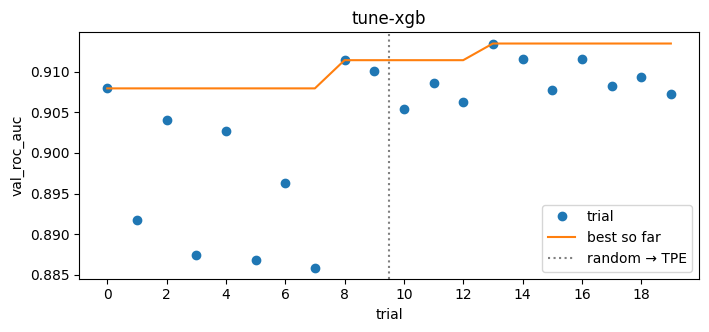

time: 28.6 s (started: 2026-09-30 14:43:58 +05:30)


In [11]:
# The search: one parent run; study.optimize() calls objective() 20 times, each call a child run inside it
optuna.logging.set_verbosity(optuna.logging.WARNING)  # objective() prints its own one-line summary per trial

with mlflow.start_run(
    run_name="tune-xgb",
    description="Optuna TPE over learning_rate, max_depth, min_child_weight; fit on train, scored on validation.",
) as tuning_run:
    mlflow.set_tag("stage", "tuning")
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=20)

    best_config = {"model_type": "xgboost", "n_estimators": 300, **study.best_params}  # typed values, ready for train.py
    mlflow.log_params({"n_trials": len(study.trials), "sampler": "TPE", "seed": SEED})
    mlflow.log_metric("best_val_roc_auc", study.best_value)
    mlflow.log_dict(best_config, "best_config.json")

    history = study.trials_dataframe()  # one row per trial: its number, value and params
    fig, ax = plt.subplots(figsize=(8, 3.2))
    ax.plot(history.number, history.value, "o", label="trial")
    ax.plot(history.number, history.value.cummax(), "-", label="best so far")
    ax.axvline(9.5, color="grey", linestyle=":", label="random → TPE")
    ax.set(xlabel="trial", ylabel="val_roc_auc", title="tune-xgb", xticks=range(0, 20, 2))
    ax.legend()
    mlflow.log_figure(fig, "plots/search_history.png")

tuning_run_id = tuning_run.info.run_id
print(f"\nbest: trial-{study.best_trial.number:02d} · val_roc_auc {study.best_value:.4f} · {best_config}")

### In the UI

**Runs → `tune-xgb` is one row, with a `+` beside its name.**

- Click the `+` to unfold the 20 trials under it; sort by `val_roc_auc`.
- Tick the trials → **Compare** → **Parallel Coordinates Plot** with `learning_rate`, `max_depth`, `min_child_weight` → `val_roc_auc`: which settings do the best trials share?
- `tune-xgb` → **Artifacts**: `best_config.json` and `plots/search_history.png`.

In [12]:
# The trials as a leaderboard: children are found through the tag MLflow sets on them, mlflow.parentRunId
trials = mlflow.search_runs(
    experiment_names=["booking-cancellations"],
    filter_string=f"tags.mlflow.parentRunId = '{tuning_run_id}'",
    order_by=["metrics.val_roc_auc DESC"],
)

top = trials.head(6)
pd.DataFrame({
    "run": top["tags.mlflow.runName"],
    "learning_rate": top["params.learning_rate"].astype(float).round(3),  # params come back as strings
    "max_depth": top["params.max_depth"],
    "min_child_weight": top["params.min_child_weight"].astype(float).round(2),
    "val_roc_auc": top["metrics.val_roc_auc"].round(4),
    "fit_time_s": top["metrics.fit_time_s"].round(1),
    "model_size_mb": top["metrics.model_size_mb"].round(1),
})

,run,learning_rate,max_depth,min_child_weight,val_roc_auc,fit_time_s,model_size_mb
0,trial-13,0.089,12,1.03,0.9134,1.8,5.1
1,trial-16,0.127,14,2.91,0.9116,2.0,4.8
2,trial-14,0.120,12,2.85,0.9115,1.6,3.6
3,trial-08,0.069,12,1.82,0.9114,1.7,4.2
4,trial-09,0.081,10,1.15,0.9100,1.5,3.0
5,trial-18,0.176,8,1.04,0.9093,1.1,1.8


time: 14.4 ms (started: 2026-09-30 14:44:27 +05:30)


**The best trials grow deep trees that split on little evidence.**

- The top four are 12 to 14 levels deep, with `min_child_weight` under 3 and `learning_rate` between 0.07 and 0.13. Today's model stops at depth 6.
- The first 10 trials are random. TPE's proposals after them found the top three: trial-13, trial-16 and trial-14. The best random trial, trial-08, is fourth.
- Validation ROC-AUC rose from 0.9114 (best random trial) to 0.9134. The best of 20 validation scores is a little optimistic by construction, which is why the test set decides in P5.

### The hand-off: tuning run → training job

**`train.py` reads the winning configuration straight from the tuning run, so nobody retypes numbers.**

- `--config runs:/<tuning_run_id>/best_config.json` → `mlflow.artifacts.load_dict(...)` inside `train.py`. The values stay typed: 12 is still an int.
- `train.py` records where its config came from, as the tag `config_source`.
- `$tuning_run_id` in a `!` line is the Python variable: IPython fills it in before the shell runs.

In [13]:
# Train the challenger: same script, same data and split, the configuration the search picked
!python train.py --config runs:/$tuning_run_id/best_config.json --run-name xgb-tuned

2026/09/30 14:44:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


test_roc_auc = 0.9169
tracking_uri = sqlite:///mlflow.db
run_id       = 17eb44ff9da04484885d4c8881b0b47c
model_uri    = models:/m-0b2e5b40d9c84dc69b3b0a2757443868


time: 11.4 s (started: 2026-09-30 14:44:27 +05:30)


In [14]:
# Both train.py runs side by side: only the configuration differs
mlflow.search_runs(
    experiment_names=["booking-cancellations"],
    filter_string="tags.stage = 'pipeline'",
    order_by=["attributes.start_time ASC"],
)[["tags.mlflow.runName", "params.max_depth", "params.min_child_weight", "params.learning_rate",
   "metrics.test_roc_auc", "metrics.model_size_mb", "tags.config_source"]]

,tags.mlflow.runName,params.max_depth,params.min_child_weight,params.learning_rate,metrics.test_roc_auc,metrics.model_size_mb,tags.config_source
0,xgb-depth6,6,1.0,0.1,0.901651,0.918926,None
1,xgb-tuned,12,1.0295437862078287,0.08910402106506982,0.916865,5.631605,runs:/8a5dcf1d2b4d4c3b91ac82ce17000bd8/best_co...


time: 11 ms (started: 2026-09-30 14:44:38 +05:30)


- `xgb-tuned`: test ROC-AUC 0.9169 against 0.9017, at 5.6 MB instead of 0.9. Whether that's worth replacing today's model is P5's question.
- Both are logged models with IDs. Neither is "the" model yet.

💬 **Think about it** — The search tuned three settings against one validation split and kept the best of 20 scores. What could make its winner look better than it really is, and what in this notebook guards against that?

✍️ **Try it** — Find the trials whose model is under 2 MB and still scored above 0.907 on validation.

<details><summary>Answer</summary>

```python
mlflow.search_runs(
    experiment_names=["booking-cancellations"],
    filter_string=f"tags.mlflow.parentRunId = '{tuning_run_id}' "
                  "and metrics.model_size_mb < 2 and metrics.val_roc_auc > 0.907",
)[["tags.mlflow.runName", "params.max_depth", "params.learning_rate",
   "metrics.val_roc_auc", "metrics.model_size_mb"]]
```

Two qualify, both 8 levels deep: `trial-18` (1.8 MB, 0.9093) and `trial-15` (1.5 MB, 0.9077). They're within 0.006 of the best trial at about a third of its size.

</details>

## P3 · Register: a name, versions, aliases

“Out of all these trained models, which model is actually the official model, which one is the challenger, and how should applications refer to them?”

```
setup ✓ → today's model ✓ → tune ✓ → [▶ REGISTER] → serve → promote → package → wrap-up
```

*You are here → **Part 3 of 7**: give both models one name, version numbers and roles.*

**The Model Registry turns "the model from run `3df2…`" into `booking-cancellation` version 2, and "the one in production" into an alias anyone can look up, or move.**

- A registered model is a name. Each registration adds the next version number, which never changes and is never reused.
- The name says what the model is for, not which algorithm it is. Both versions here are XGBoost; one built with another library would still be `booking-cancellation`, loaded from the same URI.
- An alias points at one version. Consumers load `models:/booking-cancellation@champion` and never name a version themselves.
- **What this Part builds:** the registered model `booking-cancellation`: version 1 (`xgb-depth6`) as `@champion`, version 2 (`xgb-tuned`) as `@challenger`, with descriptions and a tag.

| New word | What it means here |
|---|---|
| Model Registry | MLflow's catalogue of named models, in the same store as the runs |
| registered model | a name that holds numbered versions: `booking-cancellation` |
| model version | one logged model registered under that name: 1, 2, … |
| alias | a movable label naming exactly one version at a time: `@champion`, `@challenger` |
| `models:/<name>/<version>` | a fixed version: always the same model |
| `models:/<name>@<alias>` | whichever version the alias points at when the model is loaded |
| version description / tag | notes on a version: what it is, where it came from |
| stages | the older `Staging` / `Production` labels; deprecated since MLflow 2.9, replaced by aliases |

### P3 in one picture — two versions, two roles

**Registering gives each logged model a version number; aliases give versions roles.**

```mermaid
---
config:
  flowchart:
    wrappingWidth: 360
---
flowchart LR
    R1[("run xgb-depth6<br/>models:/m-…")]
    R2[("run xgb-tuned<br/>models:/m-…")]
    V1[("booking-cancellation<br/>version 1")]
    V2[("booking-cancellation<br/>version 2")]
    CH(["@champion"])
    CL(["@challenger"])
    USE(["consumers load<br/>models:/booking-cancellation@champion"])
    R1 -- "register_model" --> V1 --- CH
    R2 -- "register_model" --> V2 --- CL
    CH --> USE
    classDef code fill:#e8f0fe,stroke:#4285f4,color:#174ea6
    classDef stored fill:#f3e8fd,stroke:#9334e6,color:#681da8
    classDef guard fill:#fce8e6,stroke:#d93025,color:#a50e0e
    classDef endpoint fill:#e6f4ea,stroke:#34a853,color:#137333
    classDef person fill:#fff3e0,stroke:#ef6c00,color:#8a3800
    class R1,R2,V1,V2 stored
    class CH,CL person
    class USE endpoint
```

- 🟪 stored in MLflow · 🟧 aliases: a role someone decides · 🟩 the consumers.
- Consumers hold the alias, never the version: moving `@champion` (P5) changes what they load.

In [ ]:
# Register both logged models under one name: each call creates the next version number
PROJECT_NAME = "booking-cancellation"  # what the model is for, not which algorithm it is

tuned_run = mlflow.search_runs(
    experiment_names=["booking-cancellations"],
    filter_string="attributes.run_name = 'xgb-tuned'",
    order_by=["attributes.start_time DESC"],
    max_results=1,
    output_format="list",
)[0]
tuned_model_id = tuned_run.outputs.model_outputs[0].model_id

v1 = mlflow.register_model(f"models:/{current_model_id}", PROJECT_NAME)  # xgb-depth6
v2 = mlflow.register_model(f"models:/{tuned_model_id}", PROJECT_NAME)    # xgb-tuned

for mv in (v1, v2):
    print(f"version {mv.version}: source {mv.source} · run {mv.run_id} · status {mv.status}")

version 1: source models:/m-55492ff514ec4df29dcd2336d4b8ccf4 · run 361f9197642d4a11a2481a4fe06763fa · status READY
version 2: source models:/m-0b2e5b40d9c84dc69b3b0a2757443868 · run 17eb44ff9da04484885d4c8881b0b47c · status READY
time: 46.9 ms (started: 2026-09-30 14:44:38 +05:30)


Successfully registered model 'booking-cancellation'.
Created version '1' of model 'booking-cancellation'.
Registered model 'booking-cancellation' already exists. Creating a new version of this model...
Created version '2' of model 'booking-cancellation'.


- **`source`** is the logged model this version is; **`run_id`** is the run that trained it. From a version, the params, metrics and data are one hop away.
- Register the logged model's own URI, `models:/m-…`. A `runs:/<run_id>/model` URI works too, with a warning that MLflow swapped in the logged model.
- In a training script, `log_model(..., registered_model_name="booking-cancellation")` registers at logging time, so every run becomes a version. Registering by hand, as here, keeps the registry for candidates.

In [ ]:
# Roles and notes: @champion is what consumers load today, @challenger what wants to replace it
client.set_registered_model_alias(PROJECT_NAME, "champion", v1.version)
client.set_registered_model_alias(PROJECT_NAME, "challenger", v2.version)

client.update_registered_model(
    PROJECT_NAME,
    description="P(cancel) for one hotel booking. Loaded as @champion by the booking engine's risk service.",
)
client.update_model_version(PROJECT_NAME, v1.version, description="XGBoost, 300 trees of depth 6: the configuration running today.")
client.update_model_version(PROJECT_NAME, v2.version, description="Tuned by Optuna: 20 trials on validation ROC-AUC.")
client.set_model_version_tag(PROJECT_NAME, v2.version, "tuning_run", tuning_run_id)  # the search that produced it

client.get_registered_model(PROJECT_NAME).aliases  # {alias: version}

{'challenger': 2, 'champion': 1}

time: 26.1 ms (started: 2026-09-30 14:44:38 +05:30)


In [ ]:
# The registry's view: every version, its role, and (one hop away) the run and the numbers behind it
aliases = client.get_registered_model(PROJECT_NAME).aliases  # search results below leave `aliases` empty; this map doesn't

rows = []
for mv in client.search_model_versions(f"name = '{PROJECT_NAME}'"):
    run = mlflow.get_run(mv.run_id)
    rows.append({
        "version": mv.version,
        "aliases": [alias for alias, version in aliases.items() if int(version) == int(mv.version)],
        "run": run.info.run_name,
        "test_roc_auc": round(run.data.metrics["test_roc_auc"], 4),
        "model_size_mb": round(run.data.metrics["model_size_mb"], 1),
        "description": mv.description,
    })
pd.DataFrame(rows).sort_values("version")

,version,aliases,run,test_roc_auc,model_size_mb,description
1,1,[champion],xgb-depth6,0.9017,0.9,"XGBoost, 300 trees of depth 6: the configurati..."
0,2,[challenger],xgb-tuned,0.9169,5.6,Tuned by Optuna: 20 trials on validation ROC-AUC.


time: 13 ms (started: 2026-09-30 14:44:39 +05:30)


### In the UI

**Sidebar → Model registry → `booking-cancellation`.**

- The **Versions** table: **Version · Registered at · Created by · Tags · Aliases · Description**. The pencil in the **Aliases** cell edits a version's aliases.
- Click **Version 2**: **Source Run** links back to `xgb-tuned`, and **Schema** lists its 20 inputs and 1 output.
- **Stage (deprecated): None** is the old mechanism, left in the page.
- **Runs** → the **Models** column now reads `booking-cancellation v1` / `v2` beside the two `train.py` runs.

In [ ]:
# A consumer names the role, never a run or a version: this line stays the same when the champion changes
champion_model = mlflow.pyfunc.load_model(f"models:/{PROJECT_NAME}@champion")

print("@champion is version", client.get_model_version_by_alias(PROJECT_NAME, "champion").version,
      "· logged model", champion_model.metadata.model_id)
pd.DataFrame(champion_model.predict(X_test.head(3)), columns=["P(kept)", "P(cancelled)"]).round(4)  # one row per booking

@champion is version 1 · logged model m-55492ff514ec4df29dcd2336d4b8ccf4


,P(kept),P(cancelled)
0,0.6516,0.3484
1,0.0004,0.9996
2,0.8780,0.1220


time: 997 ms (started: 2026-09-30 14:44:39 +05:30)


- Two columns per row because `train.py` logged the model with `pyfunc_predict_fn="predict_proba"`.
- `get_model_version_by_alias` answers "which version is `@champion` right now?" without loading anything; P4's service uses it.

💬 **Think about it** — Who should be allowed to move `@champion`: the training job itself, a reviewer, or a CI job after automated checks? What would you want recorded each time it moves?

✍️ **Try it** — Load version 2 once by number and once by alias, and confirm they predict the same.

<details><summary>Answer</summary>

```python
by_number = mlflow.pyfunc.load_model(f"models:/{PROJECT_NAME}/2")
by_alias = mlflow.pyfunc.load_model(f"models:/{PROJECT_NAME}@challenger")
(by_number.predict(X_test) == by_alias.predict(X_test)).all()
```

</details>

## P4 · Serve: one command, then a contract

```
setup ✓ → today's model ✓ → tune ✓ → register ✓ → [▶ SERVE] → promote → package → wrap-up
```

*You are here → **Part 4 of 7**: put @champion behind HTTP twice: MLflow's own server, then a service that checks values.*

**`mlflow models serve` puts any registered model behind a REST endpoint with no code. Its only check is the model's signature: right names, right types. Right values need a contract of their own.**

- **What this Part builds:** MLflow's scoring server around `@champion`; then `app.py`'s three pieces: `Booking` (the value contract), `load_champion()`, and the routes `/predict` and `/health`.
- Every request here goes through `TestClient`: the real routing and validation, in this process, no port. Each step has its terminal command beside it, for the real server.

| New word | What it means here |
|---|---|
| `mlflow models serve` | a CLI command that starts a web server for one model URI |
| scoring server | the FastAPI app that command runs under uvicorn; `scoring_server.init(model)` builds the same app in this process |
| `/invocations` | its POST route: rows in, `{"predictions": …}` out |
| `dataframe_records` | one of its input formats: a JSON list of `{column: value}` rows |
| `--env-manager local` | serve from the current Python environment instead of building one from the model's `python_env.yaml` |
| `TestClient` | sends requests to an app inside this process: the same routing, validation and errors as over HTTP |
| route | a URL + method handled by one function: `@app.post("/predict")` |
| value contract | the values each field may take, checked before the model runs |
| `Literal[...]`, `Field(ge=0)` | pydantic: exactly one of these values · a number ≥ 0 |
| 400 / 422 | MLflow's "doesn't match the signature" / FastAPI's "doesn't match the schema" |

### P4 in one picture — six requests, two doors

**The signature stops wrong names and types; the value contract also stops wrong values.**

```mermaid
---
config:
  flowchart:
    wrappingWidth: 360
---
flowchart LR
    REQ(["BK218304<br/>as sent, and five mistakes"])
    SIG{{"MLflow /invocations<br/>signature: names and types"}}
    S200(["200 scored<br/>as sent 0.7255<br/>'Online Travel Agent' 0.3773<br/>lead_time -1: 0.2004<br/>'city hotel' 0.7771"])
    S400(["400<br/>'five months' in lead_time<br/>deposit_type missing"])
    VAL{{"app.py /predict<br/>Booking: codes and ranges"}}
    A422(["422, the field named<br/>all five mistakes"])
    A200(["200 · as sent<br/>p_cancel 0.7255 · reconfirm · version 1"])
    REQ --> SIG
    SIG --> S200
    SIG --> S400
    REQ --> VAL
    VAL --> A422
    VAL --> A200
    classDef code fill:#e8f0fe,stroke:#4285f4,color:#174ea6
    classDef stored fill:#f3e8fd,stroke:#9334e6,color:#681da8
    classDef guard fill:#fce8e6,stroke:#d93025,color:#a50e0e
    classDef endpoint fill:#e6f4ea,stroke:#34a853,color:#137333
    classDef person fill:#fff3e0,stroke:#ef6c00,color:#8a3800
    class REQ,S200,S400,A422,A200 endpoint
    class SIG,VAL guard
```

- 🟩 requests and answers · 🟥 the two checks.
- Three of MLflow's 200s are wrong answers delivered with full confidence; two of them flip a reconfirm call.

### `mlflow models serve` — in a terminal

**One command serves the champion. It resolves `@champion` once, when it starts.**

```bash
cd "<the folder that contains this notebook>"
MLFLOW_TRACKING_URI=sqlite:///mlflow.db mlflow models serve \
  -m "models:/booking-cancellation@champion" --env-manager local --port 5002
```

- `MLFLOW_TRACKING_URI` tells it which store holds the registry. `--port 5002`: 5001 is the UI.
- Its log names what it actually runs: uvicorn serving `mlflow.pyfunc.scoring_server.app:app`, the app the next cell builds in this process.

In [19]:
# The app `mlflow models serve` runs, built here around the champion: the requests below need no running server
logging.getLogger("mlflow.pyfunc.scoring_server").setLevel(logging.ERROR)  # on every 400 it logs a hint about a format not used here

model_server = TestClient(scoring_server.init(champion_model))
print("GET /ping →", model_server.get("/ping").status_code)

GET /ping → 200
time: 7.21 ms (started: 2026-09-30 14:44:40 +05:30)


In [20]:
# BK218304, from next week's arrivals: the 20 columns the signature names, as plain JSON values
upcoming = pd.read_csv("data/upcoming_arrivals.csv")
sample_booking = json.loads(upcoming.loc[upcoming.booking_id == "BK218304", FEATURES].to_json(orient="records"))[0]

response = model_server.post("/invocations", json={"dataframe_records": [sample_booking]})
print(response.status_code, response.json())
sample_booking

200 {'predictions': [[0.2744506597518921, 0.7255493402481079]]}


{'lead_time': 159,
 'stays_in_weekend_nights': 0,
 'stays_in_week_nights': 2,
 'adults': 3,
 'children': 0.0,
 'babies': 0,
 'is_repeated_guest': 0,
 'previous_cancellations': 0,
 'previous_bookings_not_canceled': 0,
 'days_in_waiting_list': 0,
 'adr': 175.5,
 'required_car_parking_spaces': 0,
 'total_of_special_requests': 0,
 'hotel': 'City Hotel',
 'meal': 'BB',
 'market_segment': 'Online TA',
 'distribution_channel': 'TA/TO',
 'reserved_room_type': 'D',
 'deposit_type': 'No Deposit',
 'customer_type': 'Transient'}

time: 9.67 ms (started: 2026-09-30 14:44:40 +05:30)


- **200** and one pair per row, `[P(kept), P(cancelled)]`. BK218304 is at 0.73: the revenue team would reconfirm it.
- The server builds its DataFrame from the JSON using the signature's types, so `"lead_time": 159` arrives as a float. An int64 DataFrame passed to `predict()` in Python would be refused.
- The same request from a terminal, while the server above runs:

```bash
curl -s -X POST http://127.0.0.1:5002/invocations -H 'Content-Type: application/json' \
  -d '{"dataframe_records": [{
    "lead_time": 159, "stays_in_weekend_nights": 0, "stays_in_week_nights": 2,
    "adults": 3, "children": 0, "babies": 0, "is_repeated_guest": 0,
    "previous_cancellations": 0, "previous_bookings_not_canceled": 0,
    "days_in_waiting_list": 0, "adr": 175.5, "required_car_parking_spaces": 0,
    "total_of_special_requests": 0, "hotel": "City Hotel", "meal": "BB",
    "market_segment": "Online TA", "distribution_channel": "TA/TO",
    "reserved_room_type": "D", "deposit_type": "No Deposit", "customer_type": "Transient"}]}'
```

### What the signature lets through

**Five requests a real caller could send, each with one mistake in it.**

- The name of a code instead of the code; an upstream system's `-1` for "unknown"; a value lower-cased on the way; text in a number field; a column dropped.

In [21]:
# Six requests to MLflow's server: BK218304 as sent, then five mistakes a real caller could make
variants = {
    "as sent": sample_booking,
    "market_segment = 'Online Travel Agent'": {**sample_booking, "market_segment": "Online Travel Agent"},  # the name, not the code
    "lead_time = -1": {**sample_booking, "lead_time": -1},                                                 # an upstream "unknown"
    "hotel = 'city hotel'": {**sample_booking, "hotel": "city hotel"},                                     # lower-cased on the way
    "lead_time = 'five months'": {**sample_booking, "lead_time": "five months"},                           # text in a number field
    "deposit_type missing": {k: v for k, v in sample_booking.items() if k != "deposit_type"},             # a column dropped upstream
}

for label, record in variants.items():
    response = model_server.post("/invocations", json={"dataframe_records": [record]})
    if response.status_code == 200:
        print(f"{response.status_code}  {label:40} p_cancel {response.json()['predictions'][0][1]:.4f}")
    else:  # MLflow's message ends with the reason, after "Error: "
        print(f"{response.status_code}  {label:40} {response.json()['message'].rsplit('Error: ', 1)[-1][:70]}")

200  as sent                                  p_cancel 0.7255
200  market_segment = 'Online Travel Agent'   p_cancel 0.3773
200  lead_time = -1                           p_cancel 0.2004
200  hotel = 'city hotel'                     p_cancel 0.7771
400  lead_time = 'five months'                'ValueError("could not convert string to float: 'five months'")'
400  deposit_type missing                     Model is missing inputs ['deposit_type'].
time: 28.7 ms (started: 2026-09-30 14:44:40 +05:30)


**The signature stopped the two mistakes it can see, names and types, and scored the three it can't.**

- **400** · text in `lead_time`, a missing `deposit_type`: refused before the model runs.
- **200** · `'Online Travel Agent'`: 0.73 → 0.38. The encoder has never seen that code, so every `market_segment` column is 0. The model answers for a booking with no sales channel, and the reconfirm call flips.
- **200** · `lead_time = -1`: 0.73 → 0.20, another flip. The trees file −1 with same-day bookings (`lead_time = 0` scores exactly the same), and only 7% of those cancel.
- **200** · `'city hotel'`: 0.73 → 0.78. A small move this time, but still a guess about a hotel the model doesn't know.
- A signature is a contract about names and types. Values need their own contract, in front of the model.

### The service: `app.py`

**`app.py` is what the booking engine calls: its own request shape, a value contract, and the model loaded through the alias.**

- `Booking` lists every field the engine sends, with the codes from P1's table as `Literal[...]` and counts as `Field(ge=0)`. FastAPI checks each request against it before the route runs. A failed check is a 422 that names the field.
- `load_champion()` resolves `@champion` to a version number once, then loads exactly that version. The answer and the version it reports can't disagree, even if the alias moves while the service runs.
- `/predict` returns the decision and its basis: `p_cancel`, `reconfirm`, the `threshold` it applied, and `model_version`.

In [22]:
# app.py, part 1: the value contract. FastAPI validates every request body against it before the route runs
class Booking(BaseModel):
    """One booking, as the booking engine sends it: codes the model was trained on, counts ≥ 0."""

    booking_id: str
    hotel: Literal["City Hotel", "Resort Hotel"]
    lead_time: int = Field(ge=0)
    stays_in_weekend_nights: int = Field(ge=0)
    stays_in_week_nights: int = Field(ge=0)
    adults: int = Field(ge=0)
    children: int = Field(ge=0)
    babies: int = Field(ge=0)
    meal: Literal["BB", "HB", "FB", "SC", "Undefined"]
    market_segment: Literal[
        "Online TA", "Offline TA/TO", "Groups", "Direct", "Corporate", "Complementary", "Aviation", "Undefined"
    ]
    distribution_channel: Literal["TA/TO", "Direct", "Corporate", "GDS", "Undefined"]
    is_repeated_guest: Literal[0, 1]
    previous_cancellations: int = Field(ge=0)
    previous_bookings_not_canceled: int = Field(ge=0)
    reserved_room_type: Literal["A", "B", "C", "D", "E", "F", "G", "H", "L", "P"]
    deposit_type: Literal["No Deposit", "Non Refund", "Refundable"]
    customer_type: Literal["Transient", "Transient-Party", "Contract", "Group"]
    days_in_waiting_list: int = Field(ge=0)
    adr: float = Field(ge=0)
    required_car_parking_spaces: int = Field(ge=0)
    total_of_special_requests: int = Field(ge=0)

time: 2.2 ms (started: 2026-09-30 14:44:40 +05:30)


In [ ]:
# app.py, part 2: which model answers. Resolve @champion to a version once, then load exactly that version
THRESHOLD = 0.5  # the revenue team reconfirms a booking at P(cancel) ≥ 0.5


def load_champion():
    """Resolve `@champion` to a version number once, then load exactly that version."""
    version = MlflowClient().get_model_version_by_alias(PROJECT_NAME, "champion").version
    model = mlflow.pyfunc.load_model(f"models:/{PROJECT_NAME}/{version}")
    return model, version


model, model_version = load_champion()  # once, at startup
print("answering with", PROJECT_NAME, "version", model_version)

answering with booking-cancellation version 1
time: 28.9 ms (started: 2026-09-30 14:44:40 +05:30)


In [ ]:
# app.py, part 3: the routes. FastAPI builds `booking` from the JSON body (or answers 422) before predict() runs
app = FastAPI(title="Maré Hotels · cancellation risk")


@app.get("/health")
def health():
    """Up, and answering with this model version."""
    return {"status": "ok", "model": PROJECT_NAME, "model_version": model_version}


@app.post("/predict")
def predict(booking: Booking):
    """Score one booking. FastAPI has already validated the body against `Booking` (or answered 422)."""
    # one-row DataFrame in the model's column order; numbers as float64, which the signature expects
    frame = pd.DataFrame([booking.model_dump()])[FEATURES].astype({c: "float64" for c in NUMERIC})
    p_cancel = float(model.predict(frame)[0, 1])  # predict returns [P(kept), P(cancelled)] per row
    return {
        "booking_id": booking.booking_id,
        "p_cancel": round(p_cancel, 4),
        "reconfirm": p_cancel >= THRESHOLD,
        "threshold": THRESHOLD,
        "model_version": model_version,
    }


service = TestClient(app)  # requests to app.py's routes, in this process
print("GET /health →", service.get("/health").json())
service.post("/predict", json={"booking_id": "BK218304", **sample_booking}).json()

GET /health → {'status': 'ok', 'model': 'booking-cancellation', 'model_version': 1}


{'booking_id': 'BK218304',
 'p_cancel': 0.7255,
 'reconfirm': True,
 'threshold': 0.5,
 'model_version': 1}

time: 9.69 ms (started: 2026-09-30 14:44:40 +05:30)


- Same model, same booking, same 0.7255 as MLflow's server, now with the decision (`reconfirm`), the rule behind it (`threshold`) and the version that made it.
- `model_dump()` turns the validated `Booking` into a plain dict; the `astype` line casts the numbers to float64, as the signature asks.

In [25]:
# The same six requests to both endpoints: ✅ the mistake was stopped · ❌ it was scored anyway
def outcome(label, response, score):
    """One table cell: status code, then the score (a 200) or why it was refused."""
    if response.status_code == 200:
        mark = "" if label == "as sent" else "❌ "  # a 200 is right only for the booking as sent
        return f"{mark}200 · p_cancel {score(response.json()):.4f}"
    return f"✅ {response.status_code}"


rows = []
for label, record in variants.items():
    mlflow_response = model_server.post("/invocations", json={"dataframe_records": [record]})
    app_response = service.post("/predict", json={"booking_id": "BK218304", **record})
    rows.append({
        "request": label,
        "MLflow /invocations": outcome(label, mlflow_response, lambda body: body["predictions"][0][1]),
        "app.py /predict": outcome(label, app_response, lambda body: body["p_cancel"]),
        "field the 422 names": ", ".join(error["loc"][-1] for error in app_response.json().get("detail", [])),
    })
pd.DataFrame(rows)

,request,MLflow /invocations,app.py /predict,field the 422 names
0,as sent,200 · p_cancel 0.7255,200 · p_cancel 0.7255,
1,market_segment = 'Online Travel Agent',❌ 200 · p_cancel 0.3773,✅ 422,market_segment
2,lead_time = -1,❌ 200 · p_cancel 0.2004,✅ 422,lead_time
3,hotel = 'city hotel',❌ 200 · p_cancel 0.7771,✅ 422,hotel
4,lead_time = 'five months',✅ 400,✅ 422,lead_time
5,deposit_type missing,✅ 400,✅ 422,deposit_type


time: 35.2 ms (started: 2026-09-30 14:44:40 +05:30)


**`app.py` stopped all five mistakes at the door, and each 422 names the field, so the caller knows what to fix.**

- MLflow's server is the right tool when the caller already speaks in model columns: another team's batch job, a quick check of a new version, a platform that serves many models the same way.
- `app.py` is the right tool when the caller is a product: it adds the allowed values, the decision rule and the version to report.
- No schema catches a plausible wrong value: `lead_time` sent in weeks (23 instead of 159) passes both doors.

💬 **Think about it** — A caller starts sending `lead_time` in weeks. Both endpoints accept it. Where, and how soon, would you notice?

### Run it for real — in a terminal

**`app.py` holds exactly the code of the three cells above, plus the constants they use.**

```bash
cd "<the folder that contains this notebook>"
uvicorn app:app --port 8001
```

- Open http://127.0.0.1:8001/docs → **POST /predict** → **Try it out**. The form is generated from `Booking`, allowed values included.
- `curl -s http://127.0.0.1:8001/health` reports the version answering.

| In this notebook | In `app.py` |
|---|---|
| `NUMERIC`, `CATEGORICAL`, `FEATURES` (P1), `PROJECT_NAME` (P3) | the same constants, at the top |
| `mlflow.set_tracking_uri("sqlite:///mlflow.db")` (P0) | `MLFLOW_TRACKING_URI` from the environment, `sqlite:///mlflow.db` by default |
| `Booking`, `THRESHOLD`, `load_champion()`, `app`, `health()`, `predict()` (P4) | identical |
| `model_server`, `service` (the `TestClient`s) | not there: uvicorn serves the app instead |

## P5 · Promote: move the alias

```
setup ✓ → today's model ✓ → tune ✓ → register ✓ → serve ✓ → [▶ PROMOTE] → package → wrap-up
```

*You are here → **Part 5 of 7**: decide with a gate, move @champion, restart, and keep the way back.*

**Promotion is one call. The work is deciding when to make it, and being able to undo it.**

- The gate compares both versions on the same test set, through the runs the registry points at.
- **What this Part builds:** the gate in code, a check of what promotion changes for next week's arrivals, the alias move, a restart of both endpoints, and the rollback as a ready call.

| New word | What it means here |
|---|---|
| promotion gate | the rule a challenger must pass before it becomes champion: here +0.002 test ROC-AUC or more, under 50 MB |
| promote | point `@champion` at the challenger's version |
| restart | both endpoints resolve `@champion` when they start, so the next start picks up the new version |
| rollback | point `@champion` back at the previous version, then restart |
| decision flip | a booking whose reconfirm yes/no differs between the two versions |

### P5 in one picture — one alias move

**The gate reads both versions' numbers; passing it moves one alias, and a restart does the rest.**

```mermaid
---
config:
  flowchart:
    wrappingWidth: 360
---
flowchart LR
    V1[("version 1 @champion<br/>test_roc_auc 0.9017")]
    V2[("version 2 @challenger<br/>test_roc_auc 0.9169 · 5.6 MB")]
    GATE{{"gate<br/>gain +0.0152, at least 0.002<br/>5.6 MB, under 50 MB"}}
    MOVE["set_registered_model_alias<br/>champion → version 2"]
    RESTART(["restart both endpoints<br/>/health: model_version 2<br/>BK218304: 0.7908"])
    BACK(["rollback<br/>champion → version 1, restart"])
    V1 --> GATE
    V2 --> GATE
    GATE -- "passed" --> MOVE --> RESTART
    RESTART -. "if version 2 misbehaves" .-> BACK
    classDef code fill:#e8f0fe,stroke:#4285f4,color:#174ea6
    classDef stored fill:#f3e8fd,stroke:#9334e6,color:#681da8
    classDef guard fill:#fce8e6,stroke:#d93025,color:#a50e0e
    classDef endpoint fill:#e6f4ea,stroke:#34a853,color:#137333
    classDef person fill:#fff3e0,stroke:#ef6c00,color:#8a3800
    class V1,V2 stored
    class GATE guard
    class MOVE code
    class RESTART endpoint
    class BACK person
```

- 🟪 stored · 🟥 the gate · 🟦 the one call · 🟩 what callers see · 🟧 the way back.
- Nothing on the serving side changes: not `app.py`, not a command line, not a config file.

In [ ]:
# The promotion gate: the challenger must beat the champion on the same test set, within the size budget
MIN_GAIN = 0.002     # a smaller gain is too close to test-set noise to be worth a change
SIZE_BUDGET_MB = 50  # the platform team's cap on model artifacts

champion = client.get_model_version_by_alias(PROJECT_NAME, "champion")
challenger = client.get_model_version_by_alias(PROJECT_NAME, "challenger")
champion_metrics = mlflow.get_run(champion.run_id).data.metrics      # version → run → what train.py logged
challenger_metrics = mlflow.get_run(challenger.run_id).data.metrics

gain = challenger_metrics["test_roc_auc"] - champion_metrics["test_roc_auc"]
gate = {
    f"test_roc_auc {challenger_metrics['test_roc_auc']:.4f} vs {champion_metrics['test_roc_auc']:.4f}: gain {gain:+.4f} ≥ {MIN_GAIN}": gain >= MIN_GAIN,
    f"model_size_mb {challenger_metrics['model_size_mb']:.1f} < {SIZE_BUDGET_MB}": challenger_metrics["model_size_mb"] < SIZE_BUDGET_MB,
}
for check, passed in gate.items():
    print("✅" if passed else "❌", check)

✅ test_roc_auc 0.9169 vs 0.9017: gain +0.0152 ≥ 0.002
✅ model_size_mb 5.6 < 50
time: 7.7 ms (started: 2026-09-30 14:44:40 +05:30)


In [ ]:
# What promotion would change for the business: next week's arrivals, scored by both versions
challenger_model = mlflow.pyfunc.load_model(f"models:/{PROJECT_NAME}@challenger")
arrivals = upcoming[FEATURES].astype({c: "float64" for c in NUMERIC})
p_champion = champion_model.predict(arrivals)[:, 1]
p_challenger = challenger_model.predict(arrivals)[:, 1]
flips = (p_champion >= THRESHOLD) != (p_challenger >= THRESHOLD)

print(f"reconfirm list: {(p_champion >= THRESHOLD).sum()} bookings (version {champion.version}) → {(p_challenger >= THRESHOLD).sum()} (version {challenger.version})")
print(f"decision flips: {flips.sum()} of {len(arrivals):,} · off the list {((p_champion >= THRESHOLD) & flips).sum()} · onto it {((p_challenger >= THRESHOLD) & flips).sum()}")

upcoming.loc[flips, ["booking_id", "arrival_date", "hotel", "lead_time", "market_segment"]].assign(
    p_champion=p_champion[flips].round(3), p_challenger=p_challenger[flips].round(3)
).head(5)

reconfirm list: 268 bookings (version 1) → 271 (version 2)
decision flips: 77 of 1,090 · off the list 37 · onto it 40


,booking_id,arrival_date,hotel,lead_time,market_segment,p_champion,p_challenger
28,BK218329,2017-08-25,City Hotel,219,Online TA,0.573,0.429
85,BK218386,2017-08-25,City Hotel,31,Online TA,0.316,0.512
140,BK218441,2017-08-25,Resort Hotel,198,Online TA,0.621,0.461
141,BK218442,2017-08-25,Resort Hotel,26,Online TA,0.463,0.553
153,BK218454,2017-08-25,Resort Hotel,38,Online TA,0.549,0.496


time: 44.1 ms (started: 2026-09-30 14:44:40 +05:30)


- About the same number of reconfirm calls (268 → 271), but 77 bookings trade places: 37 leave the list and 40 join it.
- That's what the revenue team feels on promotion day. A gate says the new model is better; this says what's different, and who should hear about it.

In [ ]:
# Promote only if the gate passed: move @champion, retire @challenger, and record the decision on the version
if all(gate.values()):
    previous_champion = champion.version  # the rollback target
    client.set_registered_model_alias(PROJECT_NAME, "champion", challenger.version)
    client.delete_registered_model_alias(PROJECT_NAME, "challenger")
    client.set_model_version_tag(
        PROJECT_NAME, challenger.version, "promoted_over", f"version {champion.version}, test_roc_auc {gain:+.4f}"
    )
else:
    print("gate failed: @champion stays on version", champion.version)

client.get_registered_model(PROJECT_NAME).aliases

{'champion': 2}

time: 11.2 ms (started: 2026-09-30 14:44:40 +05:30)


In [ ]:
# "Restart" both endpoints: each resolves @champion again when it starts. No code or config changed
model, model_version = load_champion()  # what app.py's startup line does
model_server = TestClient(scoring_server.init(mlflow.pyfunc.load_model(f"models:/{PROJECT_NAME}@champion")))  # what `mlflow models serve` does

print("app.py /health      :", service.get("/health").json())
print("app.py /predict     :", service.post("/predict", json={"booking_id": "BK218304", **sample_booking}).json())
print("MLflow /invocations :", model_server.post("/invocations", json={"dataframe_records": [sample_booking]}).json())

app.py /health      : {'status': 'ok', 'model': 'booking-cancellation', 'model_version': 2}
app.py /predict     : {'booking_id': 'BK218304', 'p_cancel': 0.7908, 'reconfirm': True, 'threshold': 0.5, 'model_version': 2}
MLflow /invocations : {'predictions': [[0.20915240049362183, 0.7908475995063782]]}
time: 72.6 ms (started: 2026-09-30 14:44:40 +05:30)


- In a terminal the restart is Ctrl+C and the same command again, for `uvicorn` and for `mlflow models serve`.
- Both endpoints now answer from version 2: BK218304 moves from 0.7255 to 0.7908, still a reconfirm.
- MLflow shows where an alias points now, not where it pointed before. The `promoted_over` tag on version 2 is the record of this move.

### Who moves the alias

**In the UI, and in a team.**

- **UI:** Model registry → `booking-cancellation` → the pencil in a version's **Aliases** cell → **Add/Edit alias** → **Save aliases**. An alias lives on one version at a time: typing `champion` on another version shows *"The "champion" alias is also being used on version 1. Adding it to this version will remove it from version 1."*
- The version page's **Promote model** button is something else: it copies the version into another registered model (one registered model per environment).
- **In a team:** a CI job runs `train.py` and the gate; a reviewer, or the job itself, moves the alias. Only the gate in code makes the decision repeatable.

✍️ **Try it** — Version 2 misbehaves in production. Roll back, restart, and check `/health` reports version 1; then promote version 2 again.

<details><summary>Answer</summary>

```python
client.set_registered_model_alias(PROJECT_NAME, "champion", previous_champion)  # roll back
model, model_version = load_champion()                                              # restart
print(service.get("/health").json())                                                # version 1

# forward again
client.set_registered_model_alias(PROJECT_NAME, "champion", challenger.version)
model, model_version = load_champion()
```

</details>

## P6 · Package: a project anyone can run

```
setup ✓ → today's model ✓ → tune ✓ → register ✓ → serve ✓ → promote ✓ → [▶ PACKAGE]
→ wrap-up
```

*You are here → **Part 6 of 7**: give the training job named commands and a declared environment, then rebuild the champion with one.*

**`train.py` runs because whoever starts it knows its flags, its environment and where the runs go. An MLflow Project writes those down in the folder, so a teammate, or a scheduler, starts the job with one command.**

- An MLflow Project is this folder plus one file, `MLproject`: the commands the project offers and the parameters each takes. A second file, `python_env.yaml`, names the environment they need.
- `mlflow run` reads both, opens a run, and starts the command inside it.
- **What this Part builds:** `MLproject` with two entry points, `train` and `retrain`; `python_env.yaml`; the runs `project-train` and `project-retrain`; and with the second, the champion rebuilt from its own `config.json`.

| New word | What it means here |
|---|---|
| MLflow Project | a folder, or a Git repository, with an `MLproject` file at its root |
| `MLproject` | a YAML file: the project's name, its environment and its entry points |
| entry point | a command the project offers, by name: `train`, `retrain` |
| parameter | a named value an entry point takes, with a type label and an optional default |
| `mlflow run` | the CLI command that runs one entry point inside a tracked run |
| `-e` · `-P name=value` | which entry point · a value for one of its parameters |
| `--experiment-name` | in a terminal, the experiment `mlflow run` opens that run in; this notebook's kernel already names it |
| `python_env.yaml` | the environment the project needs: a Python version and its packages |
| environment manager | what prepares that environment: `local` uses the current one, `uv` and `virtualenv` build it |

### P6 in one picture — one command, the champion again

**`mlflow run` opens the run, fills in the entry point's command and starts it; given the champion's config, out comes the champion's score.**

```mermaid
---
config:
  flowchart:
    wrappingWidth: 360
---
flowchart LR
    FILES["MLproject · python_env.yaml<br/>entry points: train, retrain"]
    CMD["!mlflow run . -e retrain<br/>-P config=runs:/…/config.json<br/>--env-manager local"]
    RUN[("run opened by MLflow<br/>source type PROJECT · entry point retrain")]
    TRAIN["python train.py --config runs:/…/config.json<br/>--run-name project-retrain"]
    SAME(["test_roc_auc 0.9169<br/>the champion's score, again"])
    TYPO{{"-P learning_rate=0.o5<br/>MLflow passes it on as typed"}}
    STOP(["train.py refuses it<br/>run FAILED"])
    FILES --> CMD --> RUN --> TRAIN --> SAME
    FILES -.-> TYPO --> STOP
    classDef code fill:#e8f0fe,stroke:#4285f4,color:#174ea6
    classDef stored fill:#f3e8fd,stroke:#9334e6,color:#681da8
    classDef guard fill:#fce8e6,stroke:#d93025,color:#a50e0e
    classDef endpoint fill:#e6f4ea,stroke:#34a853,color:#137333
    classDef person fill:#fff3e0,stroke:#ef6c00,color:#8a3800
    class FILES,CMD,TRAIN code
    class RUN stored
    class SAME endpoint
    class TYPO,STOP guard
```

- 🟦 files and commands · 🟪 stored in MLflow · 🟩 the result · 🟥 what `MLproject` doesn't check.
- The champion's run ID is all the command needs: the configuration comes from that run.

### `MLproject` — the whole file

**Two named commands: `train` takes a configuration as parameters, `retrain` takes it from a run.**

```yaml
# MLproject: what `mlflow run` reads. Each entry point is a command this project offers.
name: booking-cancellation

python_env: python_env.yaml   # the environment the commands need

entry_points:
  # One configuration, given as parameters. The defaults are today's model.
  train:
    parameters:
      learning_rate: {type: float, default: 0.1}
      max_depth: {type: int, default: 6}
      min_child_weight: {type: float, default: 1.0}
      n_estimators: {type: int, default: 300}
    command: >-
      python train.py --learning-rate {learning_rate} --max-depth {max_depth}
      --min-child-weight {min_child_weight} --n-estimators {n_estimators}
      --run-name project-train

  # A configuration taken from a run: a search's best_config.json, or a model's config.json.
  retrain:
    parameters:
      config: {type: string}
    command: "python train.py --config {config} --run-name project-retrain"
```

- **`train`** is `train.py` with its four flags as parameters; the defaults are today's model. **`retrain`** is P2's hand-off, `train.py --config`, as a command with a name.
- **`command`** is a template: `{max_depth}` is replaced by the parameter's value. `>-` is YAML for one long line written across several.
- **`type`** is a label for whoever reads the file. MLflow puts the value into the command as typed, and `train.py`'s argument parser is what checks it (tested below).
- **The experiment isn't named in the file.** Which experiment a run goes into is the caller's choice, made on the command line.
- The file is named exactly `MLproject`, with no extension.

### `python_env.yaml` — the environment, as a file

**The project names its Python version and points at the pins this notebook already installs.**

```yaml
# python_env.yaml: the environment `mlflow run` builds for this project's commands
# (--env-manager uv or virtualenv; --env-manager local uses the current environment instead).
python: "3.12"            # quoted: YAML would read a bare 3.12 as a number
build_dependencies:
  - pip                   # installed first; MLflow records its version with every logged model
dependencies:
  - -r requirements.txt   # one list of pins, the same one the notebook installs
```

- `-r requirements.txt` instead of a second list of packages: one set of pins, so the project and the notebook can't drift apart.
- **`--env-manager` decides what happens with this file.** `local` leaves it alone and runs in the current environment, which is what every `mlflow run` in this notebook does. `uv` and `virtualenv` build the environment first (the end of this Part).

### The first project run

**`mlflow run <project> -e <entry point> -P <name>=<value>`: MLflow opens a run, fills in the command and starts it.**

- `.` is the project: this folder. `-e train` picks the entry point. `-P max_depth=8` sets one parameter, and the other three keep their defaults.
- `--env-manager local`: run in this kernel's environment, without building one.
- **Which store and which experiment?** The ones this kernel's environment names. In P0, `set_tracking_uri` exported `MLFLOW_TRACKING_URI` and `set_experiment` exported `MLFLOW_EXPERIMENT_ID`; a `!` line inherits both. A terminal has neither (the end of this Part).

In [30]:
# The `train` entry point with one parameter changed: MLflow opens the run, then starts train.py inside it
!mlflow run . -e train -P max_depth=8 --env-manager local

2026/09/30 18:11:05 INFO mlflow.projects.utils: === Created directory /var/folders/p6/6_nprx9x22s4njm57gzb34l40000gp/T/tmp2qikfsg_ for downloading remote URIs passed to arguments of type 'path' ===
2026/09/30 18:11:05 INFO mlflow.projects.backend.local: === Running command 'python train.py --learning-rate 0.1 --max-depth 8 --min-child-weight 1.0 --n-estimators 300 --run-name project-train' in run with ID '317ca02b235049aa90356e22e98867db' === 


2026/09/30 18:11:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


test_roc_auc = 0.9092
tracking_uri = sqlite:///mlflow.db
run_id       = 317ca02b235049aa90356e22e98867db
model_uri    = models:/m-65c98ef83da54aa3853ebf99468f95fd


2026/09/30 18:11:16 INFO mlflow.projects: === Run (ID '317ca02b235049aa90356e22e98867db') succeeded ===


time: 12.7 s (started: 2026-09-30 18:11:03 +05:30)

- **`Running command`** shows the template filled in: `--max-depth 8` from `-P`, the other three values from their defaults.
- Depth 8 scores 0.9092 on test, between today's 0.9017 and the tuned 0.9169.
- MLflow logged the four parameters on the run itself, before `train.py` started. The run is named `project-train` because the command says so.

### Rebuild the champion

**A registered version leads to its run, the run holds `config.json`, and `retrain` turns that file into a model again.**

- `train.py` logs the configuration it used as `config.json` on every run (P1), so every version carries its own recipe.
- `champion` is looked up again here: since P5, `@champion` names version 2.

In [ ]:
# Rebuild the champion from its own run: that run's config.json, through the `retrain` entry point
champion = client.get_model_version_by_alias(PROJECT_NAME, "champion")  # version 2 since P5
champion_run_id = champion.run_id                                           # the run that trained it: xgb-tuned
print(f"@champion: version {champion.version} · run {champion_run_id}")

!mlflow run . -e retrain -P config=runs:/$champion_run_id/config.json --env-manager local

@champion: version 2 · run 17eb44ff9da04484885d4c8881b0b47c


2026/09/30 18:11:18 INFO mlflow.projects.utils: === Created directory /var/folders/p6/6_nprx9x22s4njm57gzb34l40000gp/T/tmpgb3nm45d for downloading remote URIs passed to arguments of type 'path' ===
2026/09/30 18:11:18 INFO mlflow.projects.backend.local: === Running command 'python train.py --config runs:/17eb44ff9da04484885d4c8881b0b47c/config.json --run-name project-retrain' in run with ID 'a094e8a75f8641e38f53b7f615b38996' === 


2026/09/30 18:11:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


test_roc_auc = 0.9169
tracking_uri = sqlite:///mlflow.db
run_id       = a094e8a75f8641e38f53b7f615b38996
model_uri    = models:/m-486834ea1a0e41009a6865f6dc3407dd


2026/09/30 18:11:29 INFO mlflow.projects: === Run (ID 'a094e8a75f8641e38f53b7f615b38996') succeeded ===


time: 13.5 s (started: 2026-09-30 18:11:16 +05:30)


In [32]:
# Every train.py run so far: the two project runs record how they were started
mlflow.search_runs(
    experiment_names=["booking-cancellations"],
    filter_string="tags.stage = 'pipeline'",
    order_by=["attributes.start_time ASC"],
)[["tags.mlflow.runName", "tags.mlflow.source.type", "tags.mlflow.project.entryPoint",
   "params.max_depth", "metrics.test_roc_auc", "tags.config_source"]]

,tags.mlflow.runName,tags.mlflow.source.type,tags.mlflow.project.entryPoint,params.max_depth,metrics.test_roc_auc,tags.config_source
0,xgb-depth6,LOCAL,None,6,0.901651,None
1,xgb-tuned,LOCAL,None,12,0.916865,runs:/8a5dcf1d2b4d4c3b91ac82ce17000bd8/best_co...
2,project-train,PROJECT,train,8,0.909245,None
3,project-retrain,PROJECT,retrain,12,0.916865,runs:/17eb44ff9da04484885d4c8881b0b47c/config....


time: 17.8 ms (started: 2026-09-30 18:16:39 +05:30)


**Same configuration, same data, same code: the same model. `project-retrain` scores 0.9169, exactly what `xgb-tuned` scored.**

- Whoever ran it needed one thing: the champion's run ID. The configuration came from the run, the command from `MLproject`.
- The two project runs say how they were started: `mlflow.source.type` is `PROJECT`, and `mlflow.project.entryPoint` names the command. The `!python train.py` runs say `LOCAL`.
- A project run also records where its code came from, in `mlflow.source.name` and, inside a Git repository, `mlflow.source.git.commit`. Source, commit, entry point and parameters are what it takes to start the same run again.
- The registry still holds two versions. A project run logs a model; registering it stays a decision (P3).

### Who checks the parameters

**`MLproject` says `learning_rate` is a float. Send it a typo: the letter `o` for a zero.**

In [33]:
# A typo in a parameter, o for 0: MLproject calls learning_rate a float, so who notices?
!mlflow run . -e train -P learning_rate=0.o5 --env-manager local

2026/09/30 18:11:31 INFO mlflow.projects.utils: === Created directory /var/folders/p6/6_nprx9x22s4njm57gzb34l40000gp/T/tmpo0l1xq5b for downloading remote URIs passed to arguments of type 'path' ===
2026/09/30 18:11:31 INFO mlflow.projects.backend.local: === Running command 'python train.py --learning-rate 0.o5 --max-depth 6 --min-child-weight 1.0 --n-estimators 300 --run-name project-train' in run with ID '9fc7c568a2e84bb79e651312dbd79fe4' === 


usage: train.py [-h] [--learning-rate LEARNING_RATE] [--max-depth MAX_DEPTH]
                [--min-child-weight MIN_CHILD_WEIGHT]
                [--n-estimators N_ESTIMATORS] [--config CONFIG]
                [--experiment EXPERIMENT] [--run-name RUN_NAME]
train.py: error: argument --learning-rate: invalid float value: '0.o5'


2026/09/30 18:11:33 ERROR mlflow.cli: === Run (ID '9fc7c568a2e84bb79e651312dbd79fe4') failed ===


time: 4.38 s (started: 2026-09-30 18:11:30 +05:30)


**`train.py` caught it, not MLflow: `float` and `int` in `MLproject` are labels.**

- MLflow put `0.o5` into the command as typed. `argparse` refused it because `train.py` declares `--learning-rate` with `type=float`; a script that read its arguments loosely would have trained on whatever arrived.
- The same goes for a misspelled name: `-P max_dpeth=8` isn't refused, it's appended to the command as `--max_dpeth 8`, and `argparse` stops that too.
- What MLflow does check: that every parameter without a default is given.
- The failed run stays in the store with `learning_rate = 0.o5`: MLflow logs each parameter as typed, before the script starts.
- **Write floats as floats.** `-P min_child_weight=2` fails with *Changing param values is not allowed*: MLflow logged `2`, then `train.py` logged the value it parsed, `2.0`, and a logged parameter can't change. `-P min_child_weight=2.0` works.

### A fresh environment, and a commit from GitHub — in a terminal

**`--env-manager local` trusts the environment you happen to be in. `uv` builds the one `python_env.yaml` describes, and a Git URL takes the code from a commit instead of this folder.**

```bash
cd "<the folder that contains this notebook>"
pip install uv        # once: MLflow calls uv to build the environment
MLFLOW_TRACKING_URI=sqlite:///mlflow.db mlflow run . -e train \
  --experiment-name booking-cancellations --env-manager uv
```

- **A terminal names the store and the experiment itself.** Leave `--experiment-name` out and the run opens in `Default`; `train.py` selects `booking-cancellations`, and MLflow stops it: *Cannot start run with ID … because active experiment ID does not match environment run ID.*
- In a `!` line of this notebook the flag isn't needed, and isn't accepted: `MLFLOW_EXPERIMENT_ID` is already set, and MLflow takes one of the two.
- The first run takes a minute or two: MLflow creates an environment under `~/.mlflow/envs/` (about 600 MB) and installs `requirements.txt` into it. Later runs find it there and start in seconds.
- It trains today's model again, test ROC-AUC 0.9017, in an environment nobody set up by hand. The run carries one more tag: `mlflow.project.env = uv`.
- With no `--env-manager` at all, MLflow picks `virtualenv` for this project: the same idea with `venv` and pip, and it needs pyenv to install the Python version.

```bash
MLFLOW_TRACKING_URI="sqlite:///$PWD/mlflow.db" mlflow run \
  "https://github.com/<owner>/<repository>#<folder>" --version <commit> \
  -e train --experiment-name booking-cancellations --env-manager uv
```

- Once this folder is in a Git repository, a URL takes the place of the `.`: MLflow clones the repository into a temporary folder, checks out `--version` (a commit or a branch) and runs the entry point there. `#<folder>` is the project's folder inside the repository.
- The tracking URI has to be absolute for this one. From the temporary folder, `sqlite:///mlflow.db` would be a different, empty file.
- The run records the URL and the commit, so "which code trained this model?" has an exact answer.

### Where Projects fit

**`MLproject` is the smallest way to make a training job something other people, and machines, can start.**

- It writes down four things any production setup needs: named commands, declared parameters, an environment built from a file, and a pinned version of the code.
- Many teams get the same four from a container image that a CI job or a scheduler starts, and never write an `MLproject`. The file earns its place where the job should run with nothing but MLflow installed: a teammate's laptop, a notebook, a rerun of an old commit.
- The two meet: `MLproject` can name a Docker image (`docker_env`) in place of `python_env.yaml`, and `mlflow run` then starts the command inside a container.

💬 **Think about it** — `project-retrain` reproduced the champion's score exactly. What had to stay the same for that to happen, and which of those things does the run record?

✍️ **Try it** — Rebuild version 1 the same way, and check that it scores 0.9017 again.

<details><summary>Answer</summary>

```python
version_1_run_id = v1.run_id  # P3's v1: the version registered from xgb-depth6
!mlflow run . -e retrain -P config=runs:/$version_1_run_id/config.json --env-manager local
```

`test_roc_auc = 0.9017`. Version 1's `config.json` holds `train.py`'s defaults, so `-e train` with no `-P` builds the same model.

</details>

## P7 · Wrap-up

```
setup ✓ → today's model ✓ → tune ✓ → register ✓ → serve ✓ → promote ✓ → package ✓
→ [▶ WRAP-UP]
```

*You are here → **Part 7 of 7**: the whole path on one page, and what builds on it.*

### Tracking, registry, serving, projects

**Each answers a different question, and changes in a different way when the model does.**

| | Experiment tracking | Model Registry | Serving | Projects |
|---|---|---|---|---|
| **Question** | what did we try, and how did it do? | which model is approved, and what did it replace? | how do other systems call it? | how does anyone else run the training? |
| **Unit** | run → params, metrics, artifacts, logged model | registered model → versions → aliases | an endpoint answering from one version | project → entry points → parameters |
| **Here** | P1–P2: `train.py`, `tune-xgb`, `xgb-tuned` | P3, P5: `booking-cancellation`, `@champion` | P4: `/invocations`, `/predict`, `/health` | P6: `MLproject`, `mlflow run . -e retrain` |
| **When a better model arrives** | a new run | an alias moves | a restart | nothing changes: the same command trains the next one |

### The workflow, end to end

**About ten calls cover this notebook.**

```python
with mlflow.start_run(run_name="tune-xgb"):                           # P2  the parent
    study.optimize(objective, n_trials=20)                            #     trials: nested=True
    mlflow.log_dict(best_config, "best_config.json")                  #     the answer, typed
!python train.py --config runs:/<tuning_run_id>/best_config.json      # P2  the challenger
mlflow.register_model("models:/m-…", PROJECT_NAME)                # P3  → version N
client.set_registered_model_alias(PROJECT_NAME, "challenger", N)  # P3  a role
mlflow.pyfunc.load_model(f"models:/{PROJECT_NAME}@champion")      # P3  every consumer
client.get_model_version_by_alias(PROJECT_NAME, "champion")       # P4  which version, once
client.set_registered_model_alias(PROJECT_NAME, "champion", N)    # P5  promote / roll back
```

```bash
mlflow models serve -m "models:/booking-cancellation@champion" --env-manager local --port 5002
uvicorn app:app --port 8001
mlflow run . -e retrain -P config=runs:/<run_id>/config.json \
  --experiment-name booking-cancellations --env-manager local
```

### Recommendations for real projects

**Small rules that keep a model replaceable.**

- **Consumers load aliases, never versions or run IDs.** `models:/<name>@champion` is the only model reference in `app.py`.
- **Resolve the alias once per process**, then load that version, so the answer and the reported version always match.
- **Put the promotion gate in code**, next to the numbers it reads, and record each promotion as a version tag.
- **Know what a promotion changes:** score recent traffic with both versions before moving the alias.
- **A signature is not a contract for values.** Put a schema in front of any model that takes requests from outside the team.
- **Hand configurations over as artifacts** (`runs:/…/best_config.json`), never as numbers copied between cells or scripts.
- **One parent run per search**, a child per attempt, and the answer logged on the parent.
- **Aliases, not stages:** stages are deprecated, and an alias can mean anything your process needs (`@champion`, `@challenger`, `@shadow`).
- **Give the training job a named command** with declared parameters and an environment file (`MLproject`), so a teammate, CI or a scheduler starts it exactly the way you do.
- **Log the configuration on every run** (`config.json`): any version can then be rebuilt from its own run.

### What comes next

**Everything below starts from `models:/booking-cancellation@champion`.**

- **Containers** — `mlflow models build-docker -m "models:/booking-cancellation@champion" -n mare-cancel` builds an image of the scoring server with the model inside; `app.py` gets its own Dockerfile.
- **Automation** — CI or a scheduler runs the `retrain` entry point and the gate on every candidate, and retrains as new bookings arrive.
- **A shared tracking server** — one `MLFLOW_TRACKING_URI` for the team, a database and object storage behind it, and permissions on who may move `@champion`.
- **Monitoring** — the inputs `/predict` receives compared with the training data (the `lead_time`-in-weeks mistake), and outcomes as bookings arrive or cancel.